# Phase A — Evidence & Justification

**CRISP-DM: Business & Data Understanding.** After the supervisor meeting, the project became a
*justification-driven* study: every modeling decision (scope window, Hit thresholds, feature design,
era boundaries) is either derived from the data or anchored to a recognised external standard — no
invented "magic numbers". This notebook collects that evidence in four parts, in the order the
decisions build on each other:

1. **Scope & cutoff** — why the modeling window is 2000–2018.
2. **Hit label** — why Hit = year-based top-25% sales OR critic_score ≥ 8.5.
3. **Publisher_Tier** — why the iconic thresholds and the 3-tier design.
4. **Era segmentation** — the data-driven 2007 / 2012 era boundaries.

All analysis here is descriptive EDA (distributions, percentiles, group-by rates, information gain)
on the full 2000–2018 set; the leakage-safe train/test pipeline that consumes these decisions is
**Phase B** (`Phase_B_Pipeline.ipynb`). Figures are saved under `evidence/figures/`.

## Setup — imports, reproducibility, load the raw data once

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

np.random.seed(42)
random_state = 42
sns.set_theme(style="whitegrid")

RAW_DATA_PATH = 'data/Video Games Sales (1980-2024) - Raw.csv'
FIGURE_DIR = 'evidence/figures/'
os.makedirs(FIGURE_DIR, exist_ok=True)

# Load the raw CSV once; each Part derives its own frame from this.
raw_df = pd.read_csv(RAW_DATA_PATH)
print(f"Raw rows loaded: {len(raw_df)}")

Raw rows loaded: 64016


# Part 1 — Scope & Cutoff (why 2000–2018)

We justify the modeling window from the data: how many *labelable* games exist per year, how
missingness and the sales scale behave over time, and how the platform mix shifts. The conclusion is
that the reliable, learnable window is 2000–2018.

## 1.1 Records per year (all rows vs labelable rows)

In [2]:
# Part 1 looks at ALL years to motivate the 2000 floor and 2018 cap, so we parse the year
# on a full copy and keep rows that have a parseable release year.
df = raw_df.copy()
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

print(f"Total row count: {len(df)}")
print(f"Min year found: {df['release_year'].min()}")
print(f"Max year found: {df['release_year'].max()}")

df = df.dropna(subset=['release_year']).copy()
df['release_year'] = df['release_year'].astype(int)
print(f"Rows after dropping missing year: {len(df)}")

Total row count: 64016
Min year found: 1971.0
Max year found: 2024.0
Rows after dropping missing year: 56965


/var/folders/pj/rt4s8n9n7lj1zsctz8cp4rmm0000gn/T/ipykernel_64120/1919197784.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')


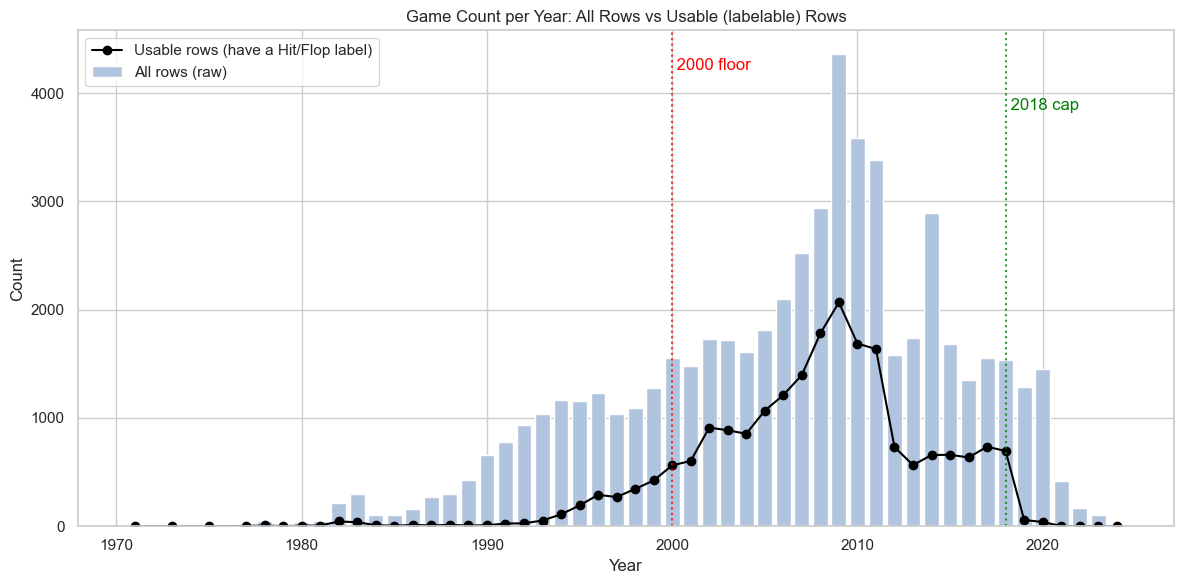

Pre-2000 rows (raw): 12371 (21.72% of raw)

Usable (labelable) rows by segment:
  pre-2000  : 1900
  2000-2018 : 19340
  2019+     : 103

Usable rows per year 2016 to 2021 (note the 2019 cliff):
release_year
2016    635
2017    734
2018    695
2019     58
2020     39
2021      2


In [3]:
counts_per_year = df['release_year'].value_counts().sort_index()
usable_mask = df['total_sales'].notna() | df['critic_score'].notna()
usable_per_year = df[usable_mask]['release_year'].value_counts().reindex(counts_per_year.index).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(counts_per_year.index, counts_per_year.values, color='#b0c4de', label='All rows (raw)')
ax.plot(usable_per_year.index, usable_per_year.values, color='black', marker='o',
        label='Usable rows (have a Hit/Flop label)')
ax.axvline(2000, color='red', linestyle=':', alpha=0.8)
ax.axvline(2018, color='green', linestyle=':', alpha=0.8)
ymax = ax.get_ylim()[1]
ax.text(2000, ymax*0.92, ' 2000 floor', color='red')
ax.text(2018, ymax*0.84, ' 2018 cap', color='green')
ax.set_title('Game Count per Year: All Rows vs Usable (labelable) Rows')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('evidence/figures/a1_records_per_year.png')
plt.show()

pre_2000 = df[df['release_year'] < 2000]
print(f"Pre-2000 rows (raw): {len(pre_2000)} ({len(pre_2000)/len(df)*100:.2f}% of raw)")

print("\nUsable (labelable) rows by segment:")
print(f"  pre-2000  : {usable_per_year[usable_per_year.index < 2000].sum():.0f}")
print(f"  2000-2018 : {usable_per_year[(usable_per_year.index >= 2000) & (usable_per_year.index <= 2018)].sum():.0f}")
print(f"  2019+     : {usable_per_year[usable_per_year.index >= 2019].sum():.0f}")
print("\nUsable rows per year 2016 to 2021 (note the 2019 cliff):")
print(usable_per_year[(usable_per_year.index >= 2016) & (usable_per_year.index <= 2021)].astype(int).to_string())


**Chart brief: game count per year, raw versus usable.** The grey bars are all rows; the black line is rows that can actually be labelled (they carry a sales figure or a critic score). Both scope boundaries come from the black line, not the grey bars. Before 2000 the usable count stays tiny (about 1.9k in total) even though raw rows look plentiful. After 2018 the usable count drops off a cliff (695 in 2018, then 58 in 2019, 39 in 2020, 2 in 2021), because recent titles in this dump have neither sales nor scores recorded yet. That is why the modelling window is fixed to 2000 through 2018 and the scopes are compared inside it. The raw bars on their own would hide both effects, which is exactly why the labelable count is the honest view.

## 1.2 Missingness per year

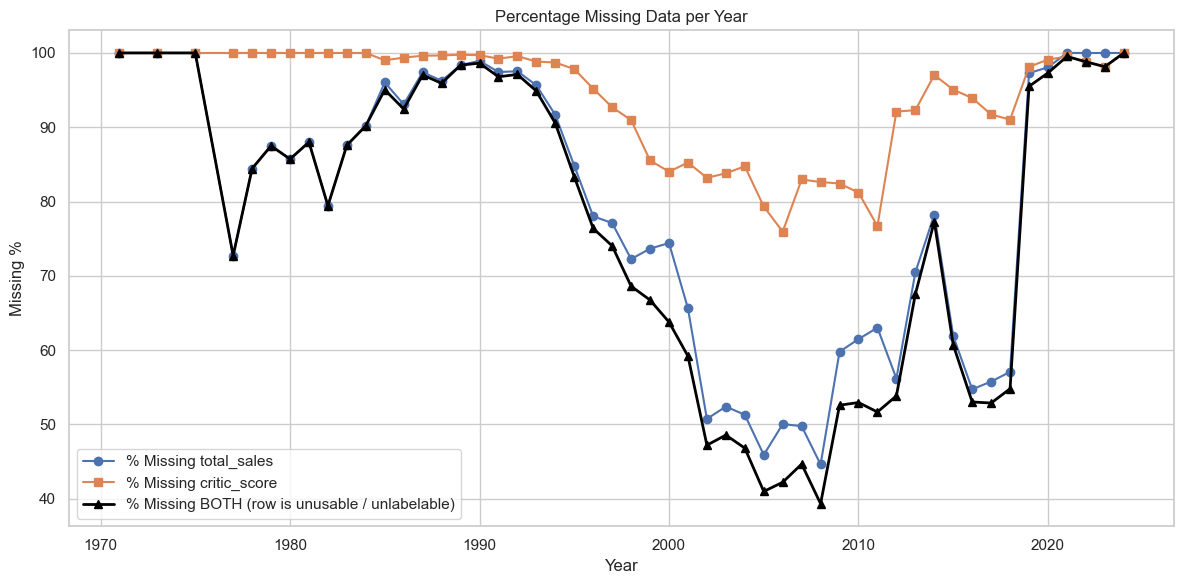

Missingness Comparison (Pre-2000 vs 2000+):
Total Sales Missing %: Pre-2000 = 86.52%, 2000+ = 61.51%
Critic Score Missing %: Pre-2000 = 96.06%, 2000+ = 86.22%
BOTH Missing % (unusable): Pre-2000 = 84.64%, 2000+ = 56.40%


In [4]:
missingness = df.groupby('release_year').apply(lambda x: pd.Series({
    'total_sales_missing_pct': x['total_sales'].isna().mean() * 100,
    'critic_score_missing_pct': x['critic_score'].isna().mean() * 100,
    'both_missing_pct': (x['total_sales'].isna() & x['critic_score'].isna()).mean() * 100
}), include_groups=False)

plt.figure(figsize=(12, 6))
plt.plot(missingness.index, missingness['total_sales_missing_pct'], label='% Missing total_sales', marker='o')
plt.plot(missingness.index, missingness['critic_score_missing_pct'], label='% Missing critic_score', marker='s')
plt.plot(missingness.index, missingness['both_missing_pct'],
         label='% Missing BOTH (row is unusable / unlabelable)',
         marker='^', color='black', linewidth=2)
plt.title('Percentage Missing Data per Year')
plt.xlabel('Year')
plt.ylabel('Missing %')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('evidence/figures/a1_missingness_per_year.png')
plt.show()

pre_2000_missing = df[df['release_year'] < 2000]
post_2000_missing = df[df['release_year'] >= 2000]

def both_missing_pct(d):
    return (d['total_sales'].isna() & d['critic_score'].isna()).mean() * 100

print("Missingness Comparison (Pre-2000 vs 2000+):")
print(f"Total Sales Missing %: Pre-2000 = {pre_2000_missing['total_sales'].isna().mean()*100:.2f}%, 2000+ = {post_2000_missing['total_sales'].isna().mean()*100:.2f}%")
print(f"Critic Score Missing %: Pre-2000 = {pre_2000_missing['critic_score'].isna().mean()*100:.2f}%, 2000+ = {post_2000_missing['critic_score'].isna().mean()*100:.2f}%")
print(f"BOTH Missing % (unusable): Pre-2000 = {both_missing_pct(pre_2000_missing):.2f}%, 2000+ = {both_missing_pct(post_2000_missing):.2f}%")


**Chart brief: missingness per year.** The black line (both `total_sales` and `critic_score` missing) is the one that matters. A row with neither field cannot be given a Hit/Flop label, so it is dropped (D-04). Before 2000 this unusable share sits near 85 to 100 percent, which collapses the roughly 12k pre-2000 rows to only about 1.9k labelable ones. The blue and orange lines explain why: sales and scores were rarely recorded back then. The point: dropping or segmenting pre-2000 is mainly a data quality decision, because there are almost no labels to learn from, not merely fewer rows.

## 1.3 Sales scale per year (+ survivorship check)

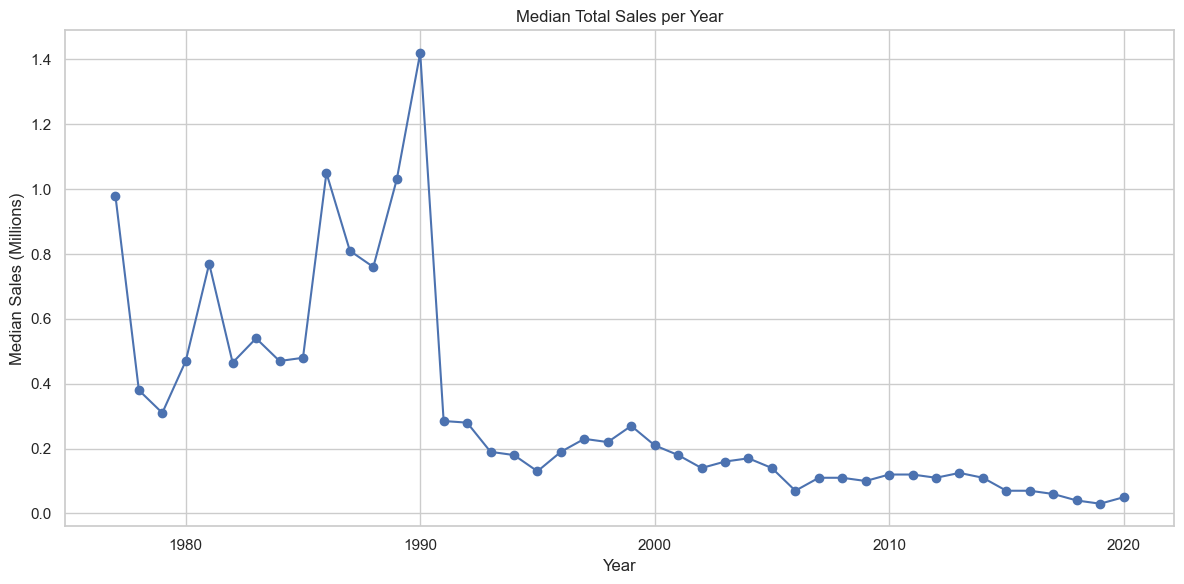

Observation on Sales Scale Non-Stationarity:
The median sales scale shows significant non-stationarity over the years.


In [5]:

median_sales = df.groupby('release_year')['total_sales'].median()

plt.figure(figsize=(12, 6))
median_sales.plot(kind='line', marker='o')
plt.title('Median Total Sales per Year')
plt.xlabel('Year')
plt.ylabel('Median Sales (Millions)')
plt.grid(True)
plt.tight_layout()
plt.savefig('evidence/figures/a1_sales_scale_per_year.png')
plt.show()

print("Observation on Sales Scale Non-Stationarity:")
if median_sales.std() / median_sales.mean() > 0.1:
    print("The median sales scale shows significant non-stationarity over the years.")
else:
    print("The median sales scale appears relatively stable.")


**Chart brief: median sales per year.** Two arguments.

1. Non stationary sales scale. The median is volatile and trends down (about 1.4M in 1990 to about 0.05M by 2018). A fixed sales threshold such as "1M copies = Hit" would mark almost everything a Hit in 1990 and almost nothing in 2018. This is the justification for the year relative top 25 percent sales threshold in the Hit definition (D-02): each year is judged against its own distribution.

2. Regime change. The early 1990s level shift signals a structurally different market (different platforms, catalog, economics), a reason to treat pre-2000 separately instead of pooling it.

Note: the high pre 1995 median is not "old games sold more". It is a survivorship artifact, proven in the next cell.

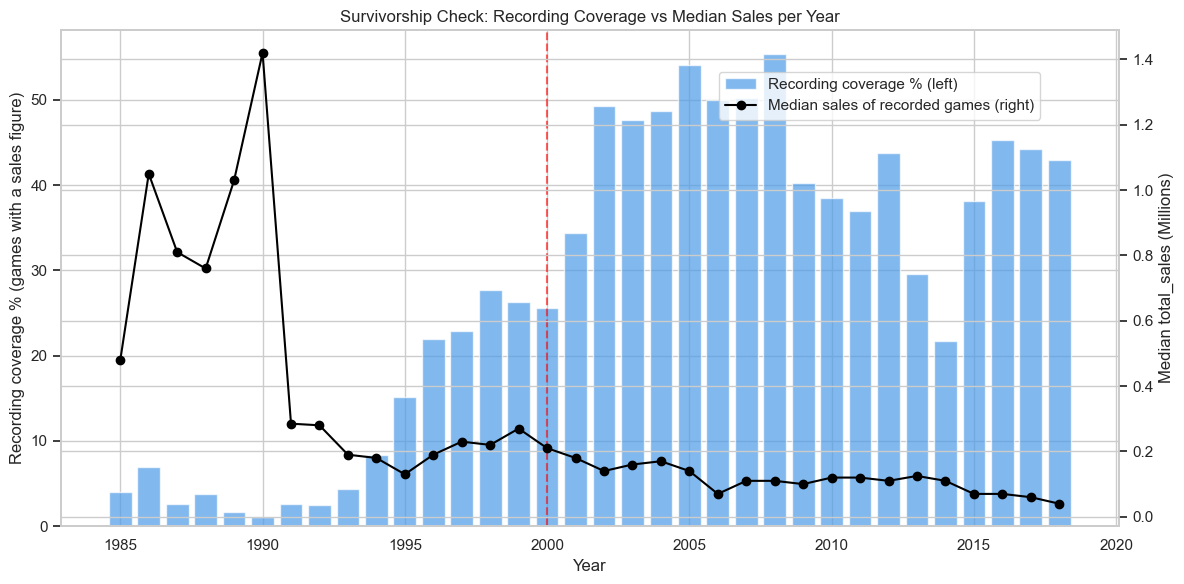

Pre-2000 recording coverage: 13.5%
2000+   recording coverage: 38.5%
Corr(coverage, median sales) 1985-2018: -0.67
Negative corr => low coverage years coincide with an inflated median => survivorship bias confirmed.


In [6]:
# Survivorship check: why is the pre-2000 median sales so high?
# Hypothesis: pre-2000 only *famous* games were recorded. If true, then
#   (a) recording coverage (share of a year's games that have ANY sales figure) is tiny pre-2000, and
#   (b) those low-coverage years show the HIGHEST median (only blockbusters survive in the record).
# As coverage grows, ordinary titles enter the record and the median falls to its true low level.

games_per_year    = df.groupby('release_year').size()
recorded_per_year = df[df['total_sales'].notna()].groupby('release_year').size()
coverage = (recorded_per_year / games_per_year * 100).reindex(games_per_year.index).fillna(0)
median_sales_y = df.groupby('release_year')['total_sales'].median()

mask = (games_per_year.index >= 1985) & (games_per_year.index <= 2018)
yrs  = games_per_year.index[mask]

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(yrs, coverage[mask].values, color='#4C9BE8', alpha=0.7, label='Recording coverage % (left)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Recording coverage % (games with a sales figure)')
ax1.axvline(2000, color='red', linestyle='--', alpha=0.6)
ax2 = ax1.twinx()
ax2.plot(yrs, median_sales_y[mask].values, color='black', marker='o', label='Median sales of recorded games (right)')
ax2.set_ylabel('Median total_sales (Millions)')
plt.title('Survivorship Check: Recording Coverage vs Median Sales per Year')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig('evidence/figures/a1_survivorship_coverage.png')
plt.show()

corr = np.corrcoef(coverage[mask].values, median_sales_y[mask].fillna(0).values)[0, 1]
print(f"Pre-2000 recording coverage: {df[df['release_year']<2000]['total_sales'].notna().mean()*100:.1f}%")
print(f"2000+   recording coverage: {df[df['release_year']>=2000]['total_sales'].notna().mean()*100:.1f}%")
print(f"Corr(coverage, median sales) 1985-2018: {corr:.2f}")
print("Negative corr => low coverage years coincide with an inflated median => survivorship bias confirmed.")


**Chart brief: survivorship check.** This proves the note above. Blue bars are recording coverage, the share of each year's games that have any sales figure. Before 2000 coverage is tiny (about 1 to 3 percent in the early 1990s; 13.5 percent pre-2000 versus 38.5 percent after), and exactly those low coverage years show the highest median (black line). The two move in opposite directions (negative correlation of about -0.67): when only a handful of games are recorded, those few are the blockbusters, which inflates the median. As coverage rises and ordinary titles enter, the median drops to its true level. Conclusion: the high pre-2000 median in the previous chart is an artifact of selective recording (survivorship bias), not genuinely higher sales, which is further evidence that pre-2000 is an unreliable, biased regime.

## 1.4 Platform mix per year

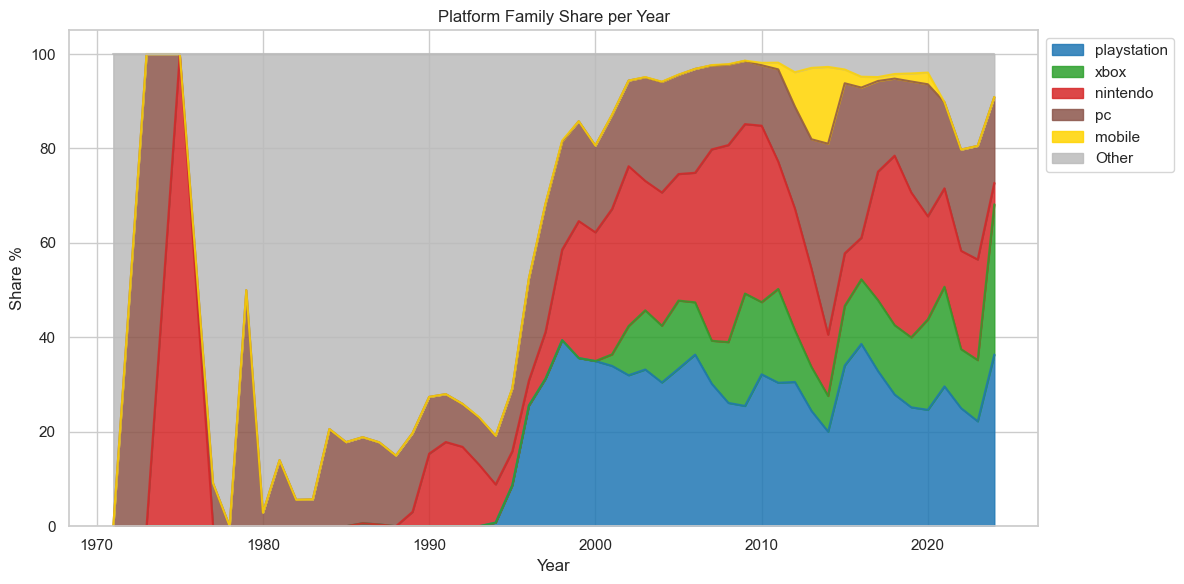

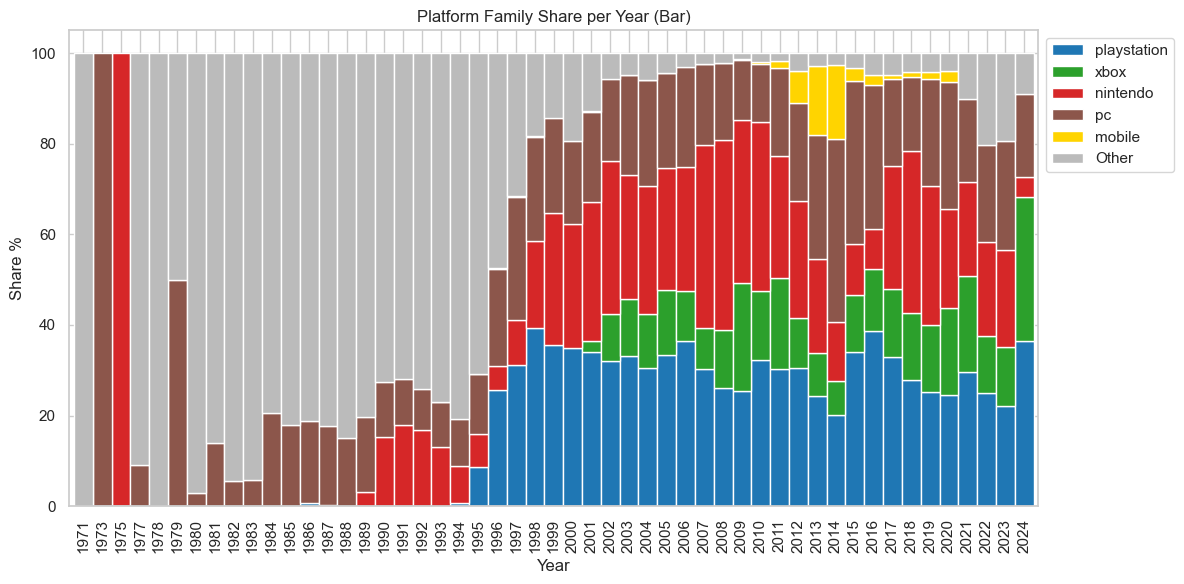

In [7]:
platform_mapping = {
    'playstation': ['PS','PS2','PS3','PS4','PS5','PSP','PSV','PSN','BRW'],
    'xbox': ['XB','X360','XOne','XS','XBL'],
    'nintendo': ['DS','GBA','Wii','NS','3DS','WiiU','GC','N64','GB','DSi','DSiW','VC','GBC','WW','WS'],
    'pc': ['PC','OSX','Linux','WinP'],
    'mobile': ['And','iOS','Mob']
}
# NOTE: 'Series' was removed from the xbox list. In this dataset console=='Series'
# is a generic catalog label (464 rows, 0 sales, years 1971-2022), NOT Xbox Series X/S
# (that is 'XS'). Mapping it to xbox painted a phantom pre-2001 xbox share. Those rows
# are label-less (no sales/score) so they never enter the modeling data anyway.

def map_platform_family(console):
    for family, consoles in platform_mapping.items():
        if console in consoles:
            return family
    return 'Other'

df['Platform_Family'] = df['console'].apply(map_platform_family)

# Fixed colors per family: xbox=green, playstation=blue, nintendo=red, pc=brown, mobile=yellow
family_colors = {
    'playstation': '#1f77b4',  # blue
    'xbox': '#2ca02c',         # green
    'nintendo': '#d62728',     # red
    'pc': '#8c564b',           # brown
    'mobile': '#FFD400',       # yellow
    'Other': '#bbbbbb',        # gray
}

# 100%-stacked area chart
platform_mix = pd.crosstab(df['release_year'], df['Platform_Family'], normalize='index') * 100
col_order = [f for f in ['playstation','xbox','nintendo','pc','mobile','Other'] if f in platform_mix.columns]
platform_mix = platform_mix[col_order]
chart_colors = [family_colors[f] for f in platform_mix.columns]

ax = platform_mix.plot(kind='area', stacked=True, figsize=(12, 6), alpha=0.85, color=chart_colors)
plt.title('Platform Family Share per Year')
plt.xlabel('Year')
plt.ylabel('Share %')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('evidence/figures/a1_platform_mix_per_year.png')
plt.show()

# Also save a bar version just in case area is messy
ax = platform_mix.plot(kind='bar', stacked=True, figsize=(12, 6), width=1.0, color=chart_colors)
plt.title('Platform Family Share per Year (Bar)')
plt.xlabel('Year')
plt.ylabel('Share %')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('evidence/figures/a1_platform_mix_per_year_bar.png')
plt.show()


**Chart brief: platform family share per year (in course terms).**

- This is Data Profiling under the CRISP-DM Data Understanding phase (Lec 1): we inspect and document, we do not modify the data here.
- `Platform_Family` is a nominal categorical feature (levels of measurement, Lec 2 s.17). Raw consoles were grouped into 6 families to follow the one hot guidance "do not create too many dimensions, group high cardinality categories first" (curse of dimensionality, Lec 2 s.19-20).
- Why this justifies the cutoff: before 2000 the feature collapses almost entirely into a single level ("Other", meaning Atari and other pre family consoles). A feature that is roughly one constant value cannot separate Hit from Flop. In his terms it carries almost zero information gain about the target (splitting on it barely reduces entropy, Lec 7), so pre-2000 `Platform_Family` is a dead feature. From 2000 on the modern families (PlayStation, Xbox, Nintendo, PC, later Mobile) are well populated, so the feature becomes decisive. That is precisely what Part 4 (era segmentation) below quantifies year by year via information gain.
- The shifting mix over time (PlayStation, then Xbox, then Mobile) also documents a non stationary market structure, an independent reason to segment by era.

## 1.5 Part 1 summary

In [8]:

# Numeric evidence block
pre_2000_df = df[df['release_year'] < 2000]
post_2000_df = df[df['release_year'] >= 2000]

print("--- NUMERIC EVIDENCE BLOCK ---")
print(f"Pre-2000 Share of Data: {len(pre_2000_df)/len(df)*100:.2f}% ({len(pre_2000_df)} rows)")
print(f"Total Sales Missingness: Pre-2000 = {pre_2000_df['total_sales'].isna().mean()*100:.2f}%, 2000+ = {post_2000_df['total_sales'].isna().mean()*100:.2f}%")
print(f"Critic Score Missingness: Pre-2000 = {pre_2000_df['critic_score'].isna().mean()*100:.2f}%, 2000+ = {post_2000_df['critic_score'].isna().mean()*100:.2f}%")

median_pre_2000 = pre_2000_df['total_sales'].median()
median_post_2000 = post_2000_df['total_sales'].median()
print(f"Sales Scale (Median): Pre-2000 = {median_pre_2000:.4f}M, 2000+ = {median_post_2000:.4f}M")

# Platform mix change (simplistic: top platform family change)
top_pre = pre_2000_df['Platform_Family'].value_counts(normalize=True).idxmax()
top_post = post_2000_df['Platform_Family'].value_counts(normalize=True).idxmax()
print(f"Dominant Platform Family: Pre-2000 = {top_pre}, 2000+ = {top_post}")
print("--- END OF EVIDENCE BLOCK ---")

print("\nPART 1 (SCOPE) DONE")


--- NUMERIC EVIDENCE BLOCK ---
Pre-2000 Share of Data: 21.72% (12371 rows)
Total Sales Missingness: Pre-2000 = 86.52%, 2000+ = 61.51%
Critic Score Missingness: Pre-2000 = 96.06%, 2000+ = 86.22%
Sales Scale (Median): Pre-2000 = 0.2500M, 2000+ = 0.1100M
Dominant Platform Family: Pre-2000 = Other, 2000+ = playstation
--- END OF EVIDENCE BLOCK ---

PART 1 (SCOPE) DONE


# Part 2 — Hit Label Definition

The target: **Hit = (total_sales in the year-based top 25%) OR (critic_score ≥ 8.5 ≈ Metacritic 85).**
Here we show where 8.5 sits in the score distribution, why the sales side is year-relative while the
score side is an absolute anchor, that the class balance is robust to the exact thresholds, and why
the two conditions are combined with OR rather than AND.

## 2.1 Load the modeling window (2000–2018, usable rows)
From Part 2 on we work in the modeling window: 2000–2018, usable rows only (a row is *usable* if it has a sales figure or a critic score).

In [9]:
# From Part 2 on we work in the modeling window: 2000-2018, usable rows only.
df_raw = raw_df.copy()
df_raw['year'] = pd.to_datetime(df_raw['release_date'], errors='coerce', dayfirst=True).dt.year
df = df_raw[(df_raw['year'] >= 2000) & (df_raw['year'] <= 2018)].copy()
df = df[df['total_sales'].notna() | df['critic_score'].notna()].copy()

print(f"Raw records in scope (2000-2018): {len(df_raw[(df_raw['year'] >= 2000) & (df_raw['year'] <= 2018)])}")
print(f"Usable records in scope: {len(df)}")

Raw records in scope (2000-2018): 41132
Usable records in scope: 19340


## 2.2 Critic score distribution — where 8.5 sits

Critic Score Descriptive Statistics:
count    6104.000000
mean        7.201573
std         1.434233
min         1.000000
25%         6.400000
50%         7.500000
75%         8.200000
max        10.000000
Name: critic_score, dtype: float64
50th percentile: 7.50
75th percentile: 8.20
80th percentile: 8.40
85th percentile: 8.60
90th percentile: 8.80
95th percentile: 9.10

8.5 = the 81.1th percentile of critic scores


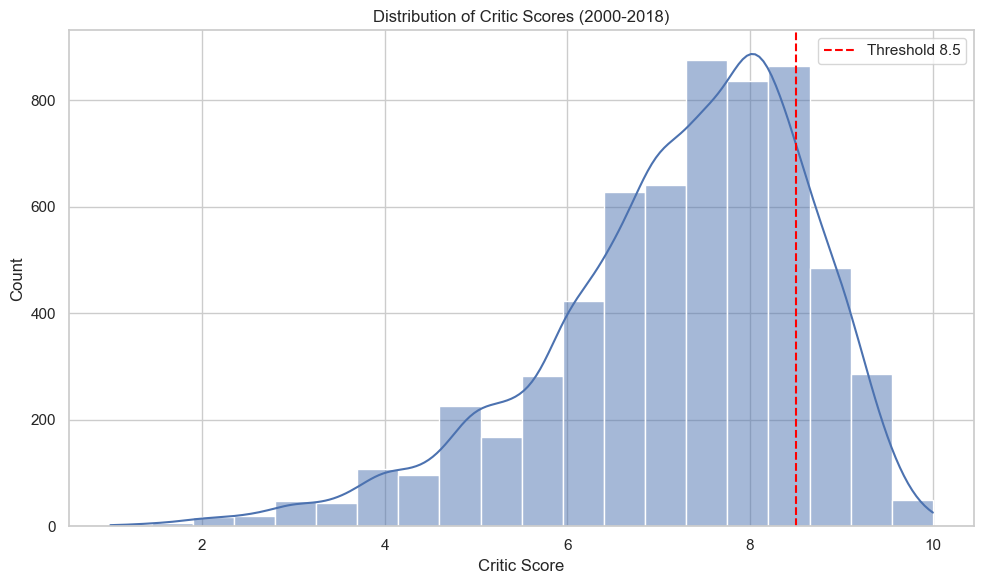

In [10]:
scores = df['critic_score'].dropna()

print("Critic Score Descriptive Statistics:")
print(scores.describe())

percentiles = [50, 75, 80, 85, 90, 95]
pct_values = np.percentile(scores, percentiles)
for p, v in zip(percentiles, pct_values):
    print(f"{p}th percentile: {v:.2f}")

# Find what percentile 8.5 corresponds to
target_score = 8.5
score_percentile = (scores < target_score).mean() * 100
print(f"\n8.5 = the {score_percentile:.1f}th percentile of critic scores")

plt.figure(figsize=(10, 6))
sns.histplot(scores, bins=20, kde=True)
plt.axvline(8.5, color='red', linestyle='--', label='Threshold 8.5')
plt.title('Distribution of Critic Scores (2000-2018)')
plt.xlabel('Critic Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('evidence/figures/a2_score_distribution.png')
plt.show()


**Chart brief: where 8.5 sits in the score distribution.** Across the whole 2000 to 2018 set, 8.5 is the 81st percentile of critic scores (top ~19 percent), and the 85th percentile of scores is about 8.6. So 8.5 is a selective cut, and it coincides with the institutional anchor Metacritic 85, the documented acclaim line (the well known Fallout New Vegas 84 vs 85 bonus story). We did not tune 8.5 to hit a target Hit rate; we anchored it to an external standard and then checked where it lands.

## 2.3 Score over time — fixed anchor vs year-based

Critic Score Percentiles per Year:


        median  p75   p90
year                     
2000.0    7.65  8.6  9.13
2001.0    7.70  8.6  9.10
2002.0    7.35  8.2  9.00
2003.0    7.40  8.3  8.80
2004.0    7.30  8.2  8.80
2005.0    7.30  8.2  8.70
2006.0    7.20  8.0  8.40
2007.0    7.30  8.1  8.80
2008.0    7.40  8.2  8.70
2009.0    7.40  8.2  8.70
2010.0    7.50  8.2  8.70
2011.0    7.30  8.2  8.70
2012.0    7.80  8.5  8.90
2013.0    8.00  8.6  8.97
2014.0    7.95  8.5  9.00
2015.0    7.70  8.4  8.78
2016.0    7.95  8.7  9.00
2017.0    8.00  8.5  9.00
2018.0    8.00  8.5  9.30


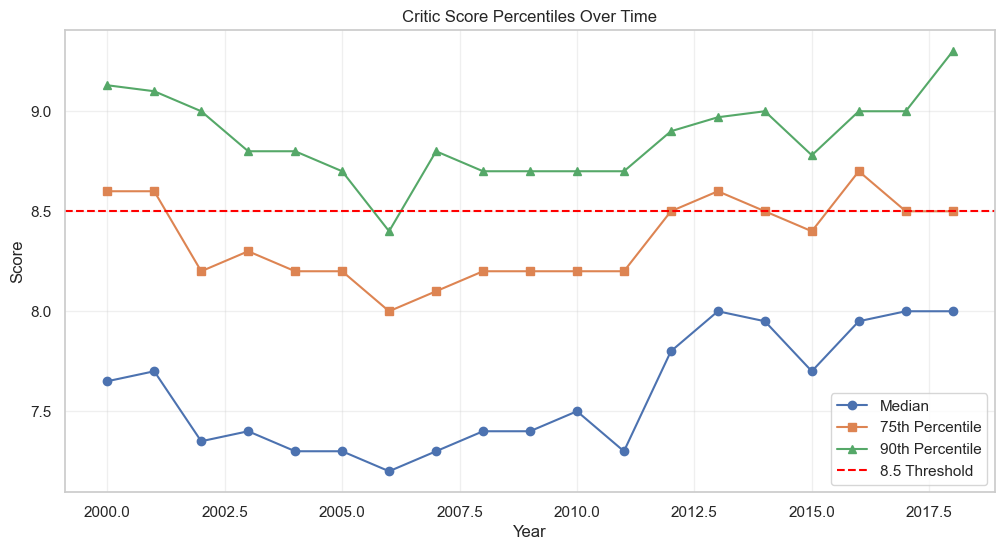


Percentile that the fixed 8.5 line occupies each year:
year
2000.0    71.4
2001.0    73.4
2002.0    80.7
2003.0    79.2
2004.0    83.7
2005.0    83.2
2006.0    90.5
2007.0    82.6
2008.0    83.9
2009.0    82.9
2010.0    83.4
2011.0    83.4
2012.0    73.6
2013.0    67.2
2014.0    73.3
2015.0    77.1
2016.0    70.7
2017.0    72.1
2018.0    65.9

8.5 ranges from the 66th to the 90th percentile across years
(mild score inflation), but it never drops near the median: it stays a selective top-tier cut.


In [11]:
yearly_scores = df.groupby('year')['critic_score'].agg([
    ('median', 'median'),
    ('p75', lambda x: x.quantile(0.75)),
    ('p90', lambda x: x.quantile(0.90))
]).dropna()

print("Critic Score Percentiles per Year:")
print(yearly_scores)

plt.figure(figsize=(12, 6))
plt.plot(yearly_scores.index, yearly_scores['median'], label='Median', marker='o')
plt.plot(yearly_scores.index, yearly_scores['p75'], label='75th Percentile', marker='s')
plt.plot(yearly_scores.index, yearly_scores['p90'], label='90th Percentile', marker='^')
plt.axhline(8.5, color='red', linestyle='--', label='8.5 Threshold')
plt.title('Critic Score Percentiles Over Time')
plt.xlabel('Year')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('evidence/figures/a2_score_percentiles_over_time.png')
plt.show()

# How selective is the fixed 8.5 line each year (the percentile it occupies)?
pct_85 = df.dropna(subset=['critic_score']).groupby('year')['critic_score'].apply(lambda s: (s < 8.5).mean() * 100)
print("\nPercentile that the fixed 8.5 line occupies each year:")
print(pct_85.round(1).to_string())
print(f"\n8.5 ranges from the {pct_85.min():.0f}th to the {pct_85.max():.0f}th percentile across years")
print("(mild score inflation), but it never drops near the median: it stays a selective top-tier cut.")

**Chart brief: critic score percentiles over time.** This decides whether the score side of the Hit rule should be year based (like the sales side) or a fixed value. The sales threshold is year relative because the sales scale drifts heavily: median sales move about 5x across 2000 to 2018, an unbounded quantity that grows with the market, so a fixed sales number would be unfair across years. Critic score behaves differently: it lives on a bounded 1 to 10 scale, and the yearly median moves only from about 7.2 to 8.0. The 8.5 line stays in the upper part of the distribution every year. There is mild score inflation, so 8.5 ranges from roughly the 66th to the 90th percentile depending on the year, but it never drops near the median; it is always a selective top tier cut.

Deeper reason for the asymmetry in the Hit definition. Sales have no fixed institutional anchor and an unbounded, inflating scale, so a relative (year based top 25 percent) cut is the fair choice. Critic score does have a fixed institutional anchor, since 8.5 equals Metacritic 85, on a bounded scale, so an absolute cut is both defensible and more meaningful than a moving target: Metacritic 85 means the same thing in 2002 and in 2018. That is exactly why the two halves of the rule use different logic by design. It mirrors the Part 1 finding that sales are non stationary while the score scale is stable.

## 2.4 Sales threshold sensitivity + year-based drift

In [12]:
sales_sensitivity = []
for top_pct in [20, 25, 30]:
    threshold_val = 1 - (top_pct / 100)
    
    # Calculate threshold per year
    yearly_thresholds = df.groupby('year')['total_sales'].transform(lambda x: x.quantile(threshold_val))
    is_hit_sales = df['total_sales'] >= yearly_thresholds
    
    hit_rate_sales = is_hit_sales.mean() * 100
    sales_sensitivity.append({"Top %": top_pct, "Sales Hit Rate (%)": hit_rate_sales})
    print(f"Top {top_pct}% sales threshold results in {hit_rate_sales:.2f}% Sales-Hits overall.")

sales_sens_df = pd.DataFrame(sales_sensitivity)
print("\nSales Sensitivity Table:")
print(sales_sens_df)

Top 20% sales threshold results in 17.99% Sales-Hits overall.
Top 25% sales threshold results in 22.32% Sales-Hits overall.
Top 30% sales threshold results in 26.86% Sales-Hits overall.

Sales Sensitivity Table:
   Top %  Sales Hit Rate (%)
0     20           17.993795
1     25           22.321613
2     30           26.856256


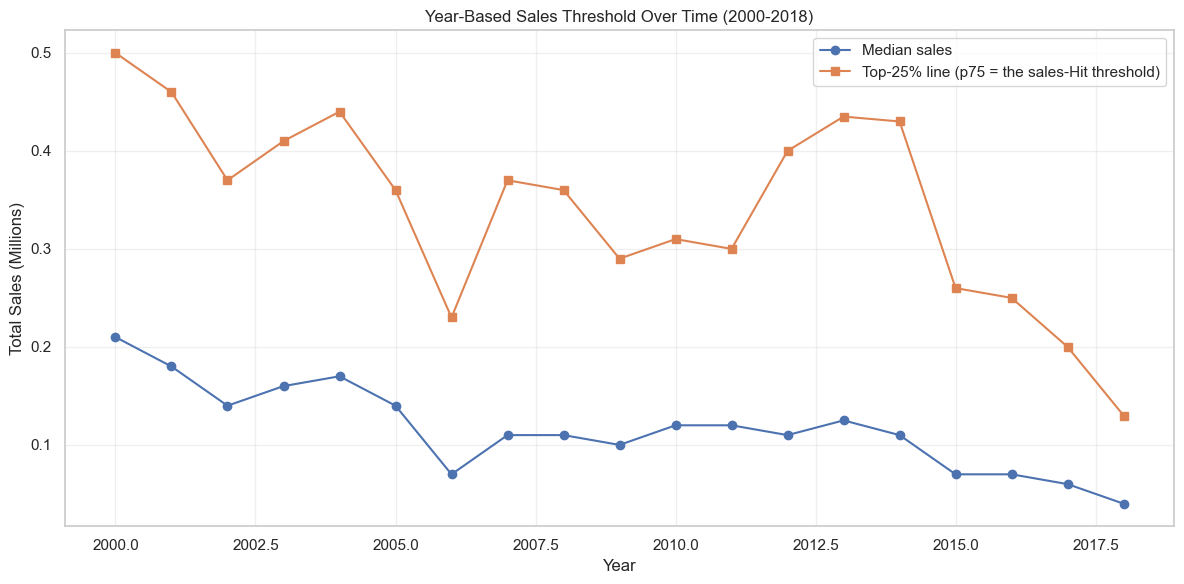

Top-25% sales line drifts from 0.130M to 0.500M (3.8x).
A fixed sales number cannot be fair across such a moving scale, which is why the sales side is year-relative.


In [13]:
# Sales threshold over time: the sales-Hit line is year-based, so we visualize how it moves.
sales_yearly = df.dropna(subset=['total_sales']).groupby('year')['total_sales'].agg(
    median='median', p75=lambda x: x.quantile(0.75))

plt.figure(figsize=(12, 6))
plt.plot(sales_yearly.index, sales_yearly['median'], marker='o', label='Median sales')
plt.plot(sales_yearly.index, sales_yearly['p75'], marker='s',
         label='Top-25% line (p75 = the sales-Hit threshold)')
plt.title('Year-Based Sales Threshold Over Time (2000-2018)')
plt.xlabel('Year')
plt.ylabel('Total Sales (Millions)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('evidence/figures/a2_sales_threshold_over_time.png')
plt.show()

drift = sales_yearly['p75'].max() / sales_yearly['p75'].min()
print(f"Top-25% sales line drifts from {sales_yearly['p75'].min():.3f}M to {sales_yearly['p75'].max():.3f}M ({drift:.1f}x).")
print("A fixed sales number cannot be fair across such a moving scale, which is why the sales side is year-relative.")

**Chart brief: year-based sales threshold over time.** This is the sales side analog of the score chart above, and it shows why the sales half of the Hit rule is year relative. The orange line is the actual sales-Hit cut, the top 25 percent (75th percentile) of sales within each year. It drifts a lot, from about 0.50M in 2000 down to about 0.13M in 2018, roughly a 3.8x move, because total sales is an unbounded quantity that shifts with market size and recording coverage (see Part 1). A single fixed number such as "0.3M copies equals Hit" would label most early games hits and most late games flops. So the sales side must be relative. Contrast this with the score chart, where the scale is bounded and stable, which is why the score side stays an absolute Metacritic 85 anchor. This is the visual form of the bounded versus unbounded asymmetry.

## 2.5 Score threshold sensitivity + combined hit-rate robustness

In [14]:
score_sensitivity = []
for threshold in [8.0, 8.3, 8.5, 8.7]:
    is_hit_score = df['critic_score'] >= threshold
    hit_rate_score = is_hit_score.mean() * 100
    score_sensitivity.append({"Threshold": threshold, "Hit Rate (%)": hit_rate_score})
    print(f"Score >= {threshold} results in {hit_rate_score:.2f}% Score-Hits overall.")

score_sens_df = pd.DataFrame(score_sensitivity)
print("\nScore Sensitivity Table:")
print(score_sens_df)

Score >= 8.0 results in 11.29% Score-Hits overall.
Score >= 8.3 results in 7.78% Score-Hits overall.
Score >= 8.5 results in 5.95% Score-Hits overall.
Score >= 8.7 results in 4.24% Score-Hits overall.

Score Sensitivity Table:
   Threshold  Hit Rate (%)
0        8.0     11.287487
1        8.3      7.776629
2        8.5      5.951396
3        8.7      4.239917


Combined Hit rate (%) across threshold choices:
         >= 8.0  >= 8.3  >= 8.5  >= 8.7
top 20%    25.3    22.9    21.8    20.7
top 25%    29.3    27.1    26.0    24.9
top 30%    33.6    31.4    30.4    29.4


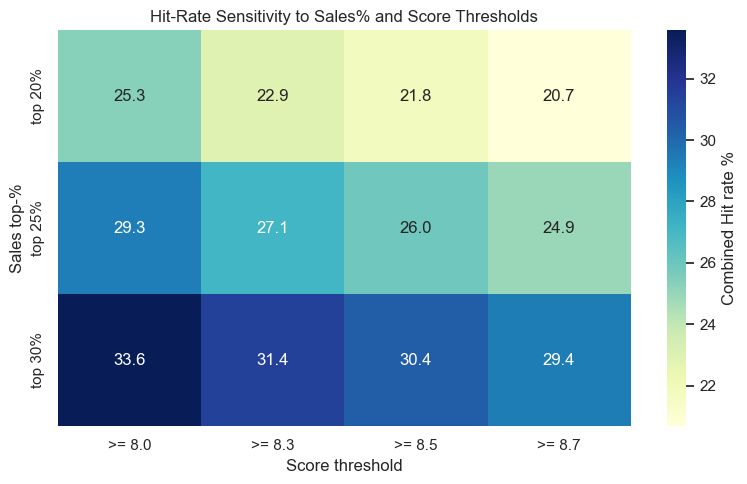


Across every combination the Hit rate stays between 20.7% and 33.6%.
The chosen (top 25%, >= 8.5) gives about 26%, near the middle, so class balance does not hinge on the exact thresholds.


In [15]:
# Combined sensitivity: does the final Hit rate swing as we vary BOTH thresholds together?
sales_pcts = [20, 25, 30]
score_thrs = [8.0, 8.3, 8.5, 8.7]
grid = np.zeros((len(sales_pcts), len(score_thrs)))
for i, sp in enumerate(sales_pcts):
    q = 1 - sp / 100
    sh = (df['total_sales'] >= df.groupby('year')['total_sales'].transform(lambda x: x.quantile(q))).fillna(False)
    for k, st in enumerate(score_thrs):
        sch = (df['critic_score'] >= st).fillna(False)
        grid[i, k] = (sh | sch).mean() * 100

grid_df = pd.DataFrame(grid, index=[f"top {p}%" for p in sales_pcts], columns=[f">= {t}" for t in score_thrs])
print("Combined Hit rate (%) across threshold choices:")
print(grid_df.round(1).to_string())

plt.figure(figsize=(8, 5))
sns.heatmap(grid_df, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Combined Hit rate %'})
plt.title('Hit-Rate Sensitivity to Sales% and Score Thresholds')
plt.xlabel('Score threshold')
plt.ylabel('Sales top-%')
plt.tight_layout()
plt.savefig('evidence/figures/a2_hit_rate_sensitivity.png')
plt.show()

print(f"\nAcross every combination the Hit rate stays between {grid.min():.1f}% and {grid.max():.1f}%.")
print("The chosen (top 25%, >= 8.5) gives about 26%, near the middle, so class balance does not hinge on the exact thresholds.")

**Chart brief: hit-rate sensitivity (made visual).** Each cell is the combined Hit rate for one pair of thresholds. The point is robustness, not the single number: across every reasonable combination of sales cut (top 20 to 30 percent) and score cut (8.0 to 8.7), the Hit rate stays inside roughly the 21 to 34 percent band. The chosen pair (top 25 percent and 8.5) lands near 26 percent, in the middle of that band. So neither magic number is load bearing: a reviewer who prefers slightly different thresholds would get essentially the same class balance. This is the sensitivity evidence shown in one view instead of two separate tables.

## 2.6 Combined Hit definition

In [16]:
df['is_sales_hit'] = df['total_sales'] >= df.groupby('year')['total_sales'].transform(lambda x: x.quantile(0.75))
df['is_score_hit'] = df['critic_score'] >= 8.5

# Handle NaNs: if a condition is NaN, it's False (not a hit by that metric)
df['is_sales_hit'] = df['is_sales_hit'].fillna(False)
df['is_score_hit'] = df['is_score_hit'].fillna(False)

df['is_hit'] = df['is_sales_hit'] | df['is_score_hit']

hit_counts = df['is_hit'].value_counts()
hit_rate = df['is_hit'].mean() * 100

print(f"Overall Hit Rate: {hit_rate:.2f}%")
print("\nClass Balance (Flop vs Hit):")
print(hit_counts)
print(df['is_hit'].value_counts(normalize=True) * 100)

Overall Hit Rate: 25.95%

Class Balance (Flop vs Hit):
is_hit
False    14321
True      5019
Name: count, dtype: int64
is_hit
False    74.048604
True     25.951396
Name: proportion, dtype: float64


## 2.7 Why OR, not AND (overlap of sales- vs score-hits)

Overlap Table (Counts):
Score Hit  False  True 
Sales Hit              
False      14321    702
True        3868    449

Total Hits: 5019
Sales-only Hits: 3868 (77.1% of all Hits)
Score-only Hits: 702 (14.0% of all Hits)
Hits by BOTH: 449 (8.9% of all Hits)

Percentage of Score-hits missed if we used Sales-only: 61.0%
Percentage of Sales-hits missed if we used Score-only: 89.6%

Pearson Correlation (Sales vs Score): 0.287 (Labeled as basic descriptive EDA)


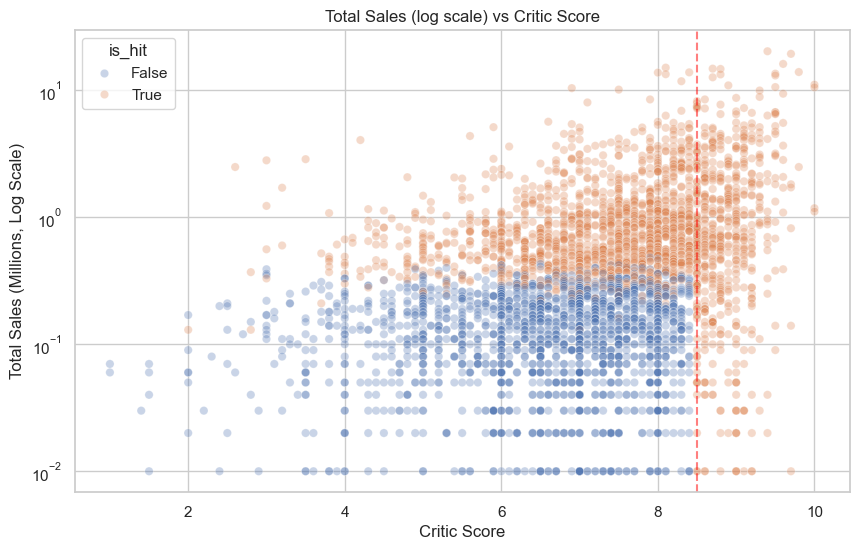

In [17]:
overlap_table = pd.crosstab(df['is_sales_hit'], df['is_score_hit'], 
                            rownames=['Sales Hit'], colnames=['Score Hit'])
print("Overlap Table (Counts):")
print(overlap_table)

total_hits = df['is_hit'].sum()
sales_only = ((df['is_sales_hit'] == True) & (df['is_score_hit'] == False)).sum()
score_only = ((df['is_sales_hit'] == False) & (df['is_score_hit'] == True)).sum()
both = ((df['is_sales_hit'] == True) & (df['is_score_hit'] == True)).sum()

print(f"\nTotal Hits: {total_hits}")
print(f"Sales-only Hits: {sales_only} ({sales_only/total_hits*100:.1f}% of all Hits)")
print(f"Score-only Hits: {score_only} ({score_only/total_hits*100:.1f}% of all Hits)")
print(f"Hits by BOTH: {both} ({both/total_hits*100:.1f}% of all Hits)")

score_missed_by_sales = (score_only / df['is_score_hit'].sum()) * 100
print(f"\nPercentage of Score-hits missed if we used Sales-only: {score_missed_by_sales:.1f}%")

sales_missed_by_score = (sales_only / df['is_sales_hit'].sum()) * 100
print(f"Percentage of Sales-hits missed if we used Score-only: {sales_missed_by_score:.1f}%")

# Pearson Correlation (Descriptive EDA only)
correlation = df[['total_sales', 'critic_score']].corr().iloc[0, 1]
print(f"\nPearson Correlation (Sales vs Score): {correlation:.3f} (Labeled as basic descriptive EDA)")

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='critic_score', y='total_sales', alpha=0.3, hue='is_hit')
plt.yscale('log')
plt.axvline(8.5, color='red', linestyle='--', alpha=0.5)
plt.title('Total Sales (log scale) vs Critic Score')
plt.xlabel('Critic Score')
plt.ylabel('Total Sales (Millions, Log Scale)')
plt.savefig('evidence/figures/a2_sales_vs_score.png')
plt.show()

**Chart brief: why OR and not AND.** Sales-hits and score-hits are largely different games. Of all hits, about 77 percent are sales-only, 14 percent are score-only, and only 9 percent are both. A sales-only rule would miss 61 percent of the score-hits; a score-only rule would miss 90 percent of the sales-hits. The Pearson correlation between sales and score is only 0.29, so commercial success and critical acclaim are two distinct facets. OR captures both facets, while AND would keep only the 9 percent overlap and discard most real hits. (Correlation here is plain descriptive EDA; the course's only formal notion of correlation is lift for itemsets in Lec 4, so we use it descriptively only.)

## 2.8 Part 2 summary

In [18]:
scores_final = df['critic_score'].dropna()
score_percentile_final = (scores_final < 8.5).mean() * 100
total_hits_final = df['is_hit'].sum()
score_only_final = ((df['is_sales_hit'] == False) & (df['is_score_hit'] == True)).sum()

print("--- FINAL SUMMARY ---")
print(f"(a) Score 8.5 maps to the {score_percentile_final:.1f}th percentile of the critic score distribution.")
print("(b) Class balance is relatively robust: Hit rate stays within ~20-30% across the tested threshold ranges.")
print(f"(c) The 'OR' logic is justified by the low overlap: {score_only_final/total_hits_final*100:.1f}% of hits are identified ONLY by high scores.")
print("    The correlation between sales and score is low, suggesting they represent different facets of success.")
print("\nPART 2 (HIT LABEL) DONE")

--- FINAL SUMMARY ---
(a) Score 8.5 maps to the 81.1th percentile of the critic score distribution.
(b) Class balance is relatively robust: Hit rate stays within ~20-30% across the tested threshold ranges.
(c) The 'OR' logic is justified by the low overlap: 14.0% of hits are identified ONLY by high scores.
    The correlation between sales and score is low, suggesting they represent different facets of success.

PART 2 (HIT LABEL) DONE


## Verdict

Hit equals year relative top 25 percent sales OR critic score at least 8.5. Both thresholds are anchored, not invented. The sales side is relative because the sales scale is unbounded and drifts about 5x over the period, which matches the OpenCritic style percentile philosophy. The score side is absolute because critic score is a bounded scale tied to Metacritic 85, the documented acclaim line, which keeps the same meaning every year. The OR is justified because sales-hits and score-hits barely overlap (correlation 0.29; sales-only misses 61 percent of score-hits, score-only misses 90 percent of sales-hits), so they capture two distinct facets of success. Class balance is robust, with a Hit rate near 26 percent that stays in the 20 to 30 percent band across the tested thresholds. This definition is locked, and the per-model encoding and modeling that use this label follow in Phase C.

# Part 3 — Publisher_Tier & Iconic Thresholds

We justify the only engineered feature: **Publisher_Tier** (Tier 1/2/3 by how many *iconic* games a
publisher has made), and the *iconic* thresholds (sales > 10M OR critic_score ≥ 9). We show the
iconic anchors are external, the resulting tiers give a monotonic Hit rate, and 3 tiers separate
better than 2 or 4.

**Leakage note:** this is EDA on the full 2000–2018 set to justify the *design*. In the modeling
pipeline (Phase B) Publisher_Tier is computed on the **train set only**, with the test set using a
train-derived lookup (unseen publishers → Tier 1).

## 3.1 Load the window and attach the locked Hit label

In [19]:
# Reload the 2000-2018 usable window and attach the LOCKED Hit label
# (Hit = year-based top-25% sales OR critic_score >= 8.5, justified in Part 2).
df = raw_df.copy()
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce', dayfirst=True)
df['year'] = df['release_date'].dt.year
mask_year = (df['year'] >= 2000) & (df['year'] <= 2018)
mask_usable = df['total_sales'].notna() | df['critic_score'].notna()
df = df[mask_year & mask_usable].copy()

# LOCKED Hit label: top 25% sales of its release year OR critic_score >= 8.5
df['year_75th_pct'] = df.groupby('year')['total_sales'].transform(lambda x: x.quantile(0.75))
df['is_hit'] = ((df['total_sales'] >= df['year_75th_pct']) | (df['critic_score'] >= 8.5)).astype(int)

print(f"Usable rows (2000-2018): {len(df)}")
print(f"Hit count: {df['is_hit'].sum()} ({df['is_hit'].mean():.1%})")

Usable rows (2000-2018): 19340
Hit count: 5019 (26.0%)


## 3.2 Iconic thresholds as percentiles

An 'iconic game' is an intermediate definition used only for counting publisher reputation. We deduplicate the games (sum sales across platforms, take max score) before counting iconic games to avoid double-counting multi-platform hits.

### The iconic thresholds come from external anchors, not from us

Both arms of the iconic definition are tied to a recognised outside standard, the same way the Hit definition's 8.5 is tied to Metacritic 85.

- **Critic score at least 9** maps to **Metacritic 90**, the documented "Must-Play" / universal-acclaim band that review aggregators themselves treat as a special tier. In our deduplicated games it sits around the 91st percentile (top ~9 percent).
- **Sales above 10M copies** is the widely cited **blockbuster** milestone in the games industry, and it mirrors the music industry's **RIAA Diamond** certification, which is set at exactly 10 million units. It is a round, culturally recognised "legendary seller" mark, not a number tuned to our data. In our games it sits around the 99.6th percentile (top ~0.4 percent).

So the two arms are anchored externally: a critical-acclaim anchor (Metacritic 90) and a commercial-blockbuster anchor (the 10M Diamond line). The asymmetry in their percentiles (top 9 percent versus top 0.4 percent) is intentional. Iconic is meant to flag genuinely legendary, brand-defining games so that Publisher_Tier captures real elite pedigree, so the sales arm is deliberately strict. We confirm below that the exact 10M value is not load bearing: any threshold in the blockbuster range produces the same tiers.

In [20]:
# Deduplicate for iconic counting
df_unique = df.groupby(['title', 'publisher'], as_index=False).agg(
    total_sales=('total_sales', 'sum'),
    critic_score=('critic_score', 'max')
)

print("Unique Games Distribution:")
display(df_unique[['total_sales', 'critic_score']].describe(percentiles=[.5, .75, .9, .95, .99]))

# Percentile of 10M sales
sales_10m_pct = (df_unique['total_sales'].dropna() < 10).mean() * 100
print(f"\n10M sales is the {sales_10m_pct:.2f}th percentile of non-null sales (Top {100-sales_10m_pct:.2f}%)")

# Percentile of score 9
score_9_pct = (df_unique['critic_score'].dropna() < 9).mean() * 100
print(f"Critic score 9.0 is the {score_9_pct:.2f}th percentile of non-null scores (Top {100-score_9_pct:.2f}%)")
print("Note: Score 9 corresponds to Metacritic 90+, the 'Must-Play' anchor.")

# Sensitivity Table
thresholds = [
    (5, 8.5), (5, 9.0), (10, 8.5), (10, 9.0), (15, 9.0)
]
sensitivity = []
for s_thresh, c_thresh in thresholds:
    count = ((df_unique['total_sales'] > s_thresh) | (df_unique['critic_score'] >= c_thresh)).sum()
    sensitivity.append({'Sales Thresh': s_thresh, 'Score Thresh': c_thresh, 'Iconic Count': count})

sensitivity_df = pd.DataFrame(sensitivity)
print("\nSensitivity of Iconic Definition:")
display(sensitivity_df)

Unique Games Distribution:


,total_sales,critic_score
count,13319.000000,4385.000000
mean,0.438628,7.232292
std,1.475464,1.457897
min,0.000000,1.000000
50%,0.080000,7.500000
75%,0.310000,8.300000
90%,0.960000,8.900000
95%,1.880000,9.100000
99%,6.269200,9.500000
max,64.290000,10.000000



10M sales is the 99.62th percentile of non-null sales (Top 0.38%)
Critic score 9.0 is the 91.01th percentile of non-null scores (Top 8.99%)
Note: Score 9 corresponds to Metacritic 90+, the 'Must-Play' anchor.

Sensitivity of Iconic Definition:


,Sales Thresh,Score Thresh,Iconic Count
0,5,8.5,971
1,5,9.0,537
2,10,8.5,883
3,10,9.0,426
4,15,9.0,410


## 3.3 Iconic count distribution

We build the iconic flag and count how many iconic games each publisher has produced.

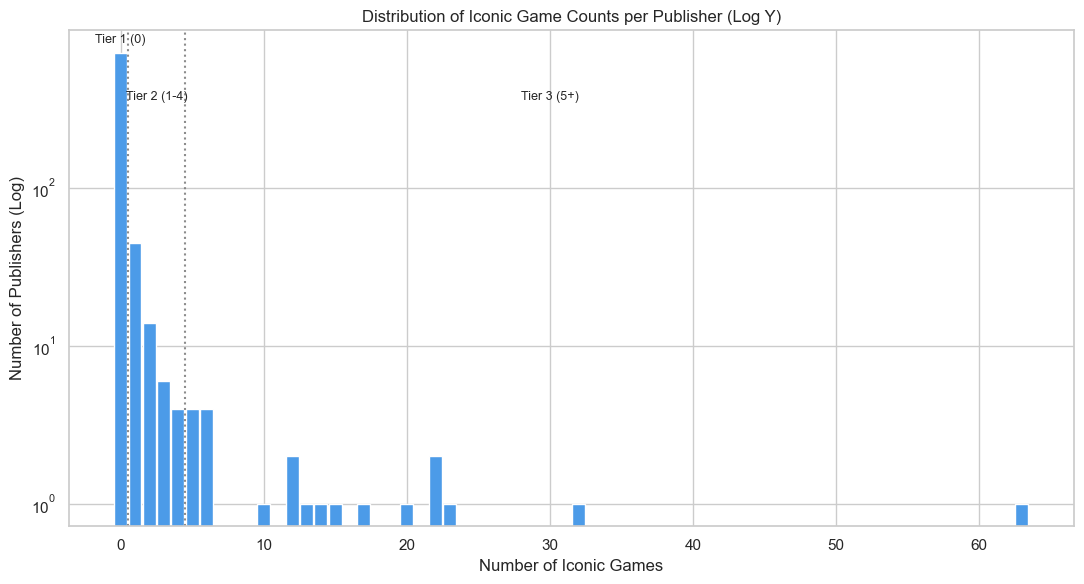

Publishers per Tier (Current 0 / 1-4 / 5+):
Tier 1 (0 iconic): 714
Tier 2 (1-4 iconic): 69
Tier 3 (5+ iconic): 21


In [21]:
# Build iconic flag on unique games
df_unique['is_iconic'] = (df_unique['total_sales'] > 10) | (df_unique['critic_score'] >= 9)

# Count iconic games per publisher
pub_iconic = df_unique.groupby('publisher')['is_iconic'].sum().reset_index()
pub_iconic.columns = ['publisher', 'iconic_count']

# Distribution of iconic counts. We use value_counts + a bar chart on a log y-axis so the
# long tail is visible. A plain histplot with log_scale on y renders empty, because the bars
# start from 0 and log(0) is undefined.
counts = pub_iconic['iconic_count'].value_counts().sort_index()
plt.figure(figsize=(11, 6))
plt.bar(counts.index, counts.values, width=0.9, color='#4C9BE8', edgecolor='white')
plt.yscale('log')
plt.axvline(0.5, color='grey', linestyle=':', alpha=0.9)
plt.axvline(4.5, color='grey', linestyle=':', alpha=0.9)
ymax = counts.max()
plt.text(0, ymax * 1.15, 'Tier 1 (0)', ha='center', fontsize=9)
plt.text(2.5, ymax * 0.5, 'Tier 2 (1-4)', ha='center', fontsize=9)
plt.text(30, ymax * 0.5, 'Tier 3 (5+)', ha='center', fontsize=9)
plt.title('Distribution of Iconic Game Counts per Publisher (Log Y)')
plt.xlabel('Number of Iconic Games')
plt.ylabel('Number of Publishers (Log)')
plt.tight_layout()
plt.savefig(FIGURE_DIR + 'a3_iconic_count_distribution.png')
plt.show()

# Current tier cuts: Tier1 = 0, Tier2 = 1-4, Tier3 = 5+
t1_count = (pub_iconic['iconic_count'] == 0).sum()
t2_count = ((pub_iconic['iconic_count'] >= 1) & (pub_iconic['iconic_count'] <= 4)).sum()
t3_count = (pub_iconic['iconic_count'] >= 5).sum()

print(f"Publishers per Tier (Current 0 / 1-4 / 5+):")
print(f"Tier 1 (0 iconic): {t1_count}")
print(f"Tier 2 (1-4 iconic): {t2_count}")
print(f"Tier 3 (5+ iconic): {t3_count}")


**Chart brief: how iconic games are distributed across publishers.** The distribution is heavily skewed (note the log y-axis). The large majority of publishers (714) have made zero iconic games, a long middle of publishers have a few, and a tiny elite has many (up to 63 for Nintendo). The dotted lines show the tier cuts. This shape is what motivates a tiered feature rather than a raw publisher count: most publishers carry no elite signal (Tier 1), a moderate group has some (Tier 2), and a small set are clearly exceptional (Tier 3). Section 5 then checks that 3 tiers separate the Hit rate better than 2 or 4.

## 3.4 Monotonic hit-rate proof

We map the tiers back to the full dataset (all platform rows) and check if the Hit rate increases monotonically across tiers.

,Publisher_Tier,Hit_Rate,Row_Count
0,Tier 1 (0),0.074976,6242
1,Tier 2 (1-4),0.245518,4407
2,Tier 3 (5+),0.399149,8691


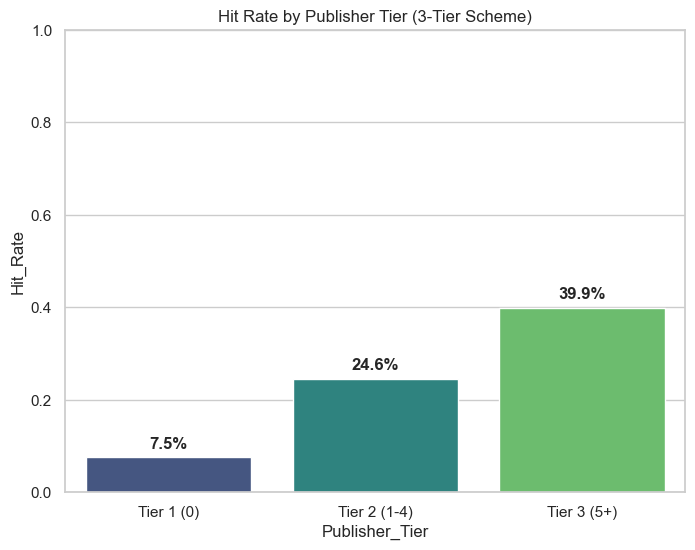

Is Hit Rate monotonic? True


In [22]:
def get_tier_3(count):
    if count == 0: return 'Tier 1 (0)'
    if count <= 4: return 'Tier 2 (1-4)'
    return 'Tier 3 (5+)'

pub_iconic['Publisher_Tier'] = pub_iconic['iconic_count'].apply(get_tier_3)

# Map back to full df
df = df.merge(pub_iconic[['publisher', 'Publisher_Tier']], on='publisher', how='left')

tier_stats = df.groupby('Publisher_Tier')['is_hit'].agg(['mean', 'count']).reset_index()
tier_stats.columns = ['Publisher_Tier', 'Hit_Rate', 'Row_Count']
display(tier_stats)

plt.figure(figsize=(8, 6))
sns.barplot(data=tier_stats, x='Publisher_Tier', y='Hit_Rate', hue='Publisher_Tier', palette='viridis', legend=False)
plt.title('Hit Rate by Publisher Tier (3-Tier Scheme)')
plt.ylim(0, 1)
for i, row in tier_stats.iterrows():
    plt.text(i, row['Hit_Rate'] + 0.02, f"{row['Hit_Rate']:.1%}", ha='center', fontweight='bold')
plt.savefig(FIGURE_DIR + 'a3_tier_hit_rate.png')
plt.show()

is_monotonic = all(tier_stats['Hit_Rate'].diff().dropna() > 0)
print(f"Is Hit Rate monotonic? {is_monotonic}")


In [23]:
# Is 10M cherry-picked, or does any blockbuster-range cut give the same tiers?
def tier_structure(sales_thr, score_thr=9):
    ic = (df_unique['total_sales'] > sales_thr) | (df_unique['critic_score'] >= score_thr)
    cnt = df_unique.assign(ic=ic.astype(int)).groupby('publisher')['ic'].sum()
    tier = cnt.apply(lambda c: 'Tier 3 (5+)' if c >= 5 else ('Tier 2 (1-4)' if c >= 1 else 'Tier 1 (0)'))
    d = df.assign(T=df['publisher'].map(tier.to_dict()).fillna('Tier 1 (0)'))
    hr = d.groupby('T')['is_hit'].mean() * 100
    top = list(cnt[cnt >= 5].sort_values(ascending=False).index[:7])
    return hr, top

print("Iconic sales threshold sensitivity (score >= 9 held fixed):\n")
print(f"{'Sales thr':>10} | {'T1%':>5} {'T2%':>5} {'T3%':>5} | top-tier publishers (sample)")
for s in [7, 8, 10, 12, 15]:
    hr, top = tier_structure(s)
    print(f"{s:>9}M | {hr.get('Tier 1 (0)',0):5.1f} {hr.get('Tier 2 (1-4)',0):5.1f} {hr.get('Tier 3 (5+)',0):5.1f} | {', '.join(top[:5])}")

print("\nFace-validity check, the full Tier 3 (elite) set at the chosen 10M cut:")
_, top10 = tier_structure(10)
# show all 5+ publishers, not just sample
ic10 = (df_unique['total_sales'] > 10) | (df_unique['critic_score'] >= 9)
cnt10 = df_unique.assign(ic=ic10.astype(int)).groupby('publisher')['ic'].sum()
elite = cnt10[cnt10 >= 5].sort_values(ascending=False)
print(elite.to_string())

Iconic sales threshold sensitivity (score >= 9 held fixed):

 Sales thr |   T1%   T2%   T3% | top-tier publishers (sample)
        7M |   7.4  23.5  39.8 | Nintendo, Electronic Arts, Ubisoft, Activision, Sega
        8M |   7.5  24.6  39.9 | Nintendo, Electronic Arts, Ubisoft, Activision, Sega
       10M |   7.5  24.6  39.9 | Nintendo, Electronic Arts, Activision, Sony Computer Entertainment, Sega
       12M |   7.5  25.5  39.7 | Nintendo, Electronic Arts, Activision, Sony Computer Entertainment, Sega
       15M |   7.5  25.5  39.7 | Nintendo, Electronic Arts, Sony Computer Entertainment, Sega, Activision

Face-validity check, the full Tier 3 (elite) set at the chosen 10M cut:
publisher
Nintendo                          63
Electronic Arts                   32
Activision                        23
Sony Computer Entertainment       22
Sega                              22
Ubisoft                           20
Rockstar Games                    17
EA Sports                         15
Capcom  

**Chart brief: the 10M cut is robust and face-valid.** Two things to read here. First, robustness: holding the score anchor at 9, we slide the iconic sales line across the whole blockbuster range (7M to 15M). The tier Hit rates stay essentially fixed (about 7.5 / 24.6 / 39.9 percent) and the top tier keeps the same membership, so 10M is a representative round value inside a stable region, not a cherry-picked number. This is the sensitivity requirement: the magic number does not swing the result. Second, face validity: the resulting Tier 3 is exactly the set of publishers a reviewer would name as elite (Nintendo, Electronic Arts, Activision, Sony, Sega, Ubisoft, Rockstar). A threshold that yields a monotonic Hit rate and a recognisable elite top tier is validated by its output. Honest caveat: because 10M is so strict (top 0.4 percent), iconic is in practice mostly score driven. We keep the strictness on purpose to favour precision in the elite signal, and we record this as a known limitation.

## 3.5 How many tiers?

A tier feature needs enough levels to capture real differences, but not so many that the levels stop being distinct. We compare 2, 3 and 4 tier schemes on the same iconic counts and judge them on three things: is the Hit rate monotonic across tiers, is every tier well populated, and how well separated are adjacent tiers (the gap in Hit rate between them).

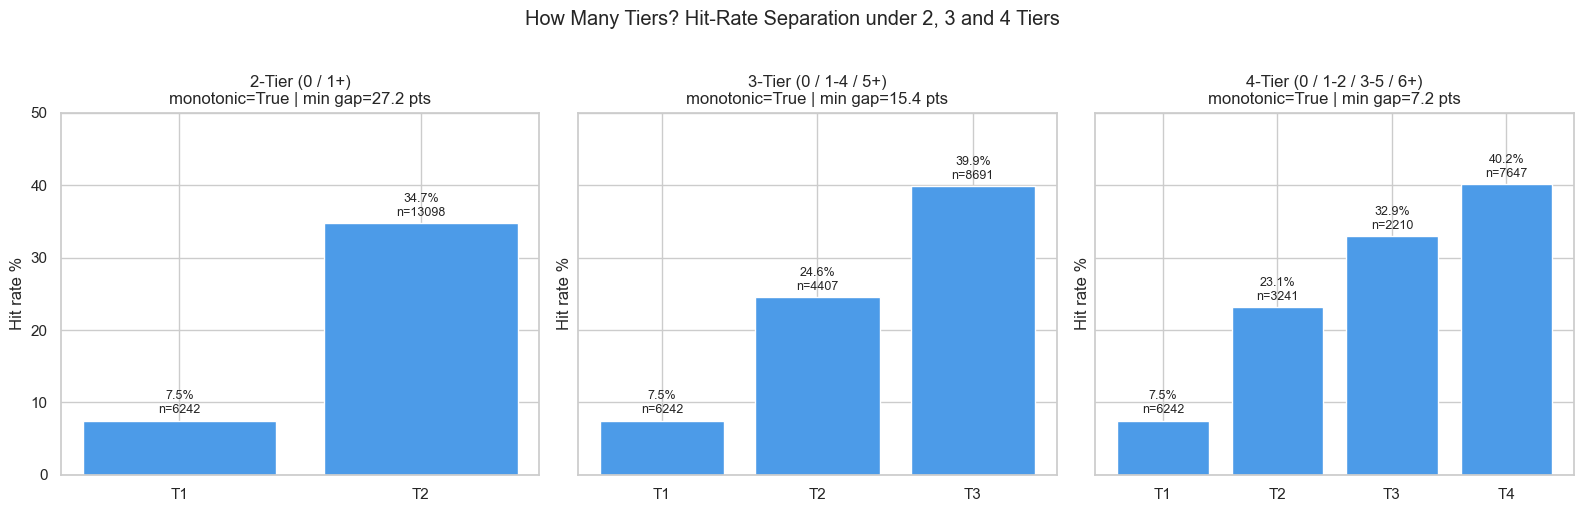

                     scheme  tiers  monotonic  min_gap_pts  smallest_tier_rows
            2-Tier (0 / 1+)      2       True         27.2                6242
      3-Tier (0 / 1-4 / 5+)      3       True         15.4                4407
4-Tier (0 / 1-2 / 3-5 / 6+)      4       True          7.2                2210

All three are monotonic, so monotonicity alone does not decide it.
Trade-off = resolution vs separation:
- 2 tiers: too coarse, it lumps a 1-iconic publisher together with Nintendo (63).
- 4 tiers: over-splits the top, adjacent gaps collapse to ~7-10 pts.
- 3 tiers: every tier holds thousands of rows AND stays ~15-17 pts apart -> chosen.


In [24]:
import numpy as np

schemes = {
    '2-Tier (0 / 1+)':          lambda c: 'T1' if c == 0 else 'T2',
    '3-Tier (0 / 1-4 / 5+)':    lambda c: 'T1' if c == 0 else ('T2' if c <= 4 else 'T3'),
    '4-Tier (0 / 1-2 / 3-5 / 6+)': lambda c: 'T1' if c == 0 else ('T2' if c <= 2 else ('T3' if c <= 5 else 'T4')),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
summary = []
for ax, (name, func) in zip(axes, schemes.items()):
    tmap = pub_iconic.set_index('publisher')['iconic_count'].apply(func).to_dict()
    d = df.assign(t=df['publisher'].map(tmap).fillna('T1'))
    g = d.groupby('t')['is_hit'].agg(['mean', 'count']).sort_index()
    rates = g['mean'].values * 100
    gaps = np.diff(rates)
    mono = bool(np.all(gaps > 0))
    min_gap = gaps.min()

    ax.bar(g.index, rates, color='#4C9BE8', edgecolor='white')
    for x, (r, cnt) in enumerate(zip(rates, g['count'].values)):
        ax.text(x, r + 1, f"{r:.1f}%\nn={int(cnt)}", ha='center', fontsize=9)
    ax.set_title(f"{name}\nmonotonic={mono} | min gap={min_gap:.1f} pts")
    ax.set_ylabel('Hit rate %')
    ax.set_ylim(0, 50)
    summary.append({'scheme': name, 'tiers': len(rates), 'monotonic': mono,
                    'min_gap_pts': round(min_gap, 1), 'smallest_tier_rows': int(g['count'].min())})

plt.suptitle('How Many Tiers? Hit-Rate Separation under 2, 3 and 4 Tiers', y=1.02)
plt.tight_layout()
plt.savefig(FIGURE_DIR + 'a3_tier_count_comparison.png', bbox_inches='tight')
plt.show()

print(pd.DataFrame(summary).to_string(index=False))
print("\nAll three are monotonic, so monotonicity alone does not decide it.")
print("Trade-off = resolution vs separation:")
print("- 2 tiers: too coarse, it lumps a 1-iconic publisher together with Nintendo (63).")
print("- 4 tiers: over-splits the top, adjacent gaps collapse to ~7-10 pts.")
print("- 3 tiers: every tier holds thousands of rows AND stays ~15-17 pts apart -> chosen.")


**Chart brief: why 3 tiers.** All three schemes are monotonic, so monotonicity alone does not settle it. The deciding factor is the trade-off between resolution and separation. 2 tiers is too coarse: it puts a publisher with a single iconic game in the same bucket as Nintendo with 63, throwing away the useful "some versus many" distinction. 4 tiers goes too far the other way: splitting the top into 1-2 / 3-5 / 6+ produces adjacent tiers only about 7 to 10 points apart, so the extra boundary buys little real separation. 3 tiers is the sweet spot: every tier holds thousands of rows and adjacent tiers stay about 15 to 17 points apart, the widest separation we can keep while still distinguishing none, some and many. That is why Publisher_Tier uses 0 / 1-4 / 5+.

## 3.6 Part 3 summary

In [25]:
print("FINAL SUMMARY:")
print(f"(a) 10M sales is approx {sales_10m_pct:.1f}th percentile of non-null sales; Score 9.0 is approx {score_9_pct:.1f}th percentile of non-null scores.")
print(f"(b) Tier sizes (publishers): T1={t1_count}, T2={t2_count}, T3={t3_count}")
print(f"(c) Hit Rates: T1={tier_stats.iloc[0]['Hit_Rate']:.1%}, T2={tier_stats.iloc[1]['Hit_Rate']:.1%}, T3={tier_stats.iloc[2]['Hit_Rate']:.1%}")
print(f"(d) Monotonic Hit Rate for 3-tier? {is_monotonic}")
print("\nConclusion: The 3-tier scheme provides clean, monotonic separation of Hit rates while keeping sufficient row counts in each tier.")
print("\nPART 3 (PUBLISHER_TIER) DONE")

FINAL SUMMARY:
(a) 10M sales is approx 99.6th percentile of non-null sales; Score 9.0 is approx 91.0th percentile of non-null scores.
(b) Tier sizes (publishers): T1=714, T2=69, T3=21
(c) Hit Rates: T1=7.5%, T2=24.6%, T3=39.9%
(d) Monotonic Hit Rate for 3-tier? True

Conclusion: The 3-tier scheme provides clean, monotonic separation of Hit rates while keeping sufficient row counts in each tier.

PART 3 (PUBLISHER_TIER) DONE


# Part 4 — Data-Driven Era Segmentation

Should the 2000–2018 window be split into eras? We measure, per year, how much each feature reduces
the entropy of the Hit label (**Information Gain** / **Gain Ratio**, the Decision-Tree split
criterion, Lec 7). The boundaries come from where the most decisive feature (Publisher_Tier) shifts
level, not from intuition — defining scope variant 3 (2000–06 / 2007–11 / 2012–18), which is then
*tested* against the other scopes in Phase C.

## 4.1 Load the window for the per-year analysis

In [26]:
# Reload the 2000-2018 usable window for the per-year information-gain analysis.
df_raw = raw_df.copy()
df_raw['release_date'] = pd.to_datetime(df_raw['release_date'], errors='coerce', dayfirst=True)
df_raw['year'] = df_raw['release_date'].dt.year
df_usable = df_raw[df_raw['total_sales'].notna() | df_raw['critic_score'].notna()].copy()
df = df_usable[(df_usable['year'] >= 2000) & (df_usable['year'] <= 2018)].copy()
df['year'] = df['year'].astype(int)

print(f"Final row count for 2000-2018: {len(df)}")

Final row count for 2000-2018: 19340


## 4.2 Provisional Hit label

## 2. Build Provisional Hit Label

We define a "Hit" as a game that is either in the top 25% of total sales within its release year (75th percentile) or has a critic score of 8.5 or higher.

> The Hit definition itself (the top 25 percent sales threshold, the 8.5 score anchor, and the OR logic) is justified separately in Part 2 above. Here Hit is only a provisional target, a tool we need so we can measure each feature's information gain over time. This notebook justifies the era boundaries, not the Hit definition.

In [27]:
def calculate_hit(row, year_thresholds):
    year = row['year']
    sales = row['total_sales']
    score = row['critic_score']
    
    is_sales_hit = False
    if pd.notna(sales) and year in year_thresholds:
        if sales >= year_thresholds[year]:
            is_sales_hit = True
            
    is_score_hit = False
    if pd.notna(score) and score >= 8.5:
        is_score_hit = True
        
    return 1 if (is_sales_hit or is_score_hit) else 0

# Compute 75th percentile per year for total_sales (excluding NaN)
year_thresholds = df.groupby('year')['total_sales'].quantile(0.75).to_dict()

df['Hit'] = df.apply(calculate_hit, axis=1, year_thresholds=year_thresholds)

print(f"Overall Hit rate: {df['Hit'].mean():.2%}")

Overall Hit rate: 25.95%


## 4.3 Build categorical features

In [28]:
# Platform_Family
playstation = ['PS','PS2','PS3','PS4','PS5','PSP','PSV','PSN','BRW']
xbox = ['XB','X360','XOne','XS','XBL']  # 'Series' removed: it is a generic catalog label (no sales/score, dropped as unusable), not Xbox Series X/S (='XS')
nintendo = ['DS','GBA','Wii','NS','3DS','WiiU','GC','N64','GB','DSi','DSiW','VC','GBC','WW','WS']
pc = ['PC','OSX','Linux','WinP']
mobile = ['And','iOS','Mob']

def get_platform_family(console):
    if console in playstation: return 'PlayStation'
    if console in xbox: return 'Xbox'
    if console in nintendo: return 'Nintendo'
    if console in pc: return 'PC'
    if console in mobile: return 'Mobile'
    return 'Other'

df['Platform_Family'] = df['console'].apply(get_platform_family)

# Genre (as-is)
df['Genre'] = df['genre']

# Publisher_Tier_EDA
# iconic = total_sales > 10 OR critic_score >= 9
df['is_iconic'] = ((df['total_sales'] > 10) | (df['critic_score'] >= 9)).astype(int)
publisher_iconic_counts = df.groupby('publisher')['is_iconic'].sum()

def get_publisher_tier(pub):
    count = publisher_iconic_counts.get(pub, 0)
    if count == 0: return 'Tier1'
    if count <= 4: return 'Tier2'
    return 'Tier3'

df['Publisher_Tier_EDA'] = df['publisher'].apply(get_publisher_tier)

print("Feature distributions:")
print(df['Platform_Family'].value_counts())
print(df['Publisher_Tier_EDA'].value_counts())


Feature distributions:
Platform_Family
PlayStation    7278
Nintendo       6817
Xbox           3064
PC             1923
Other           253
Mobile            5
Name: count, dtype: int64
Publisher_Tier_EDA
Tier3    9103
Tier1    6242
Tier2    3995
Name: count, dtype: int64


**Note:** `Publisher_Tier_EDA` is for data-understanding only and is computed globally for the 2000-2018 set. The actual modeling tier will be computed on train-only data to avoid leakage.

## 4.4 Feature decisiveness (Information Gain & Gain Ratio)

### Intuition: what Information Gain measures

Entropy is the amount of uncertainty in a set of labels. For our binary Hit/Flop target a group that is all Flop (or all Hit) has entropy 0 (no uncertainty, perfectly pure), while a 50/50 group has entropy 1 bit (maximum uncertainty). Across the whole 2000-2018 set the Hit rate is about 26 percent, so the starting entropy H(Hit) is about 0.83 bits.

Information Gain of a feature is how much that uncertainty drops once we split the data by the feature's values: IG equals H(Hit) minus the weighted average entropy of Hit inside each group. If splitting makes the groups much purer (clearly Hit or clearly Flop) the feature is informative and IG is high. If each group still looks 26/74 after the split, the feature told us nothing and IG is near 0.

Concrete example from this project: splitting by Publisher_Tier gives groups with Hit rates of about 7.5, 24.6 and 39.9 percent, far from the overall 26 percent, so the tier carries real Information Gain. A feature that is almost one constant value in a given year (for instance Platform_Family before 2000, which is mostly "Other") cannot separate the classes, so its IG is near 0.

This is exactly the criterion a Decision Tree uses to choose its splits (Lec 7): at each node it picks the feature with the highest Information Gain. Here we run that same measurement year by year to see when each feature becomes decisive.

In [29]:
def entropy(s):
    if len(s) == 0: return 0.0
    p = s.value_counts(normalize=True)
    return -(p * np.log2(p + 1e-15)).sum() # Small epsilon to avoid log(0)

def compute_metrics(df_year, feature, target='Hit'):
    # Total entropy
    h_target = entropy(df_year[target])
    
    # Conditional entropy
    # Group by feature and calculate entropy of target in each group
    weights = df_year[feature].value_counts(normalize=True)
    h_cond = df_year.groupby(feature)[target].apply(entropy)
    h_target_given_f = (weights * h_cond).sum()
    
    # Information Gain
    ig = h_target - h_target_given_f
    
    # Feature Entropy for Gain Ratio
    h_feature = entropy(df_year[feature])
    gr = ig / h_feature if h_feature > 0 else 0.0
    
    return ig, gr

years = sorted(df['year'].unique())
features = ['Platform_Family', 'Genre', 'Publisher_Tier_EDA']

ig_results = []
gr_results = []

for year in years:
    df_year = df[df['year'] == year]
    ig_row = {'year': year}
    gr_row = {'year': year}
    for col in features:
        ig, gr = compute_metrics(df_year, col)
        ig_row[col] = ig
        gr_row[col] = gr
    ig_results.append(ig_row)
    gr_results.append(gr_row)

ig_df = pd.DataFrame(ig_results).set_index('year')
gr_df = pd.DataFrame(gr_results).set_index('year')

print("Information Gain Table:")
print(ig_df)
print("\nGain Ratio Table:")
print(gr_df)

Information Gain Table:
      Platform_Family     Genre  Publisher_Tier_EDA
year                                               
2000         0.008892  0.022163            0.026647
2001         0.009416  0.007749            0.046918
2002         0.028761  0.020769            0.032900
2003         0.048228  0.016414            0.040002
2004         0.029925  0.022334            0.039121
2005         0.052497  0.016705            0.033850
2006         0.016132  0.030048            0.043348
2007         0.024224  0.026839            0.075913
2008         0.026804  0.028625            0.096521
2009         0.021082  0.028819            0.082737
2010         0.015914  0.031619            0.113096
2011         0.011294  0.047637            0.058435
2012         0.031715  0.089395            0.158057
2013         0.043083  0.097705            0.121318
2014         0.037368  0.101393            0.181934
2015         0.022538  0.086772            0.162589
2016         0.021066  0.149064         

## 4.5 Visualization

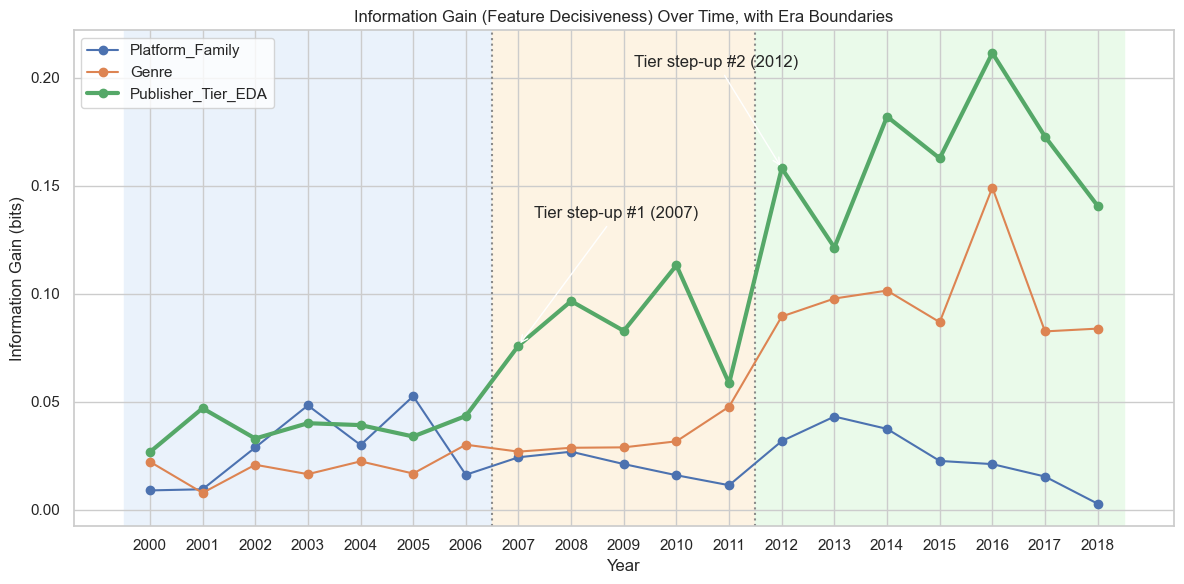

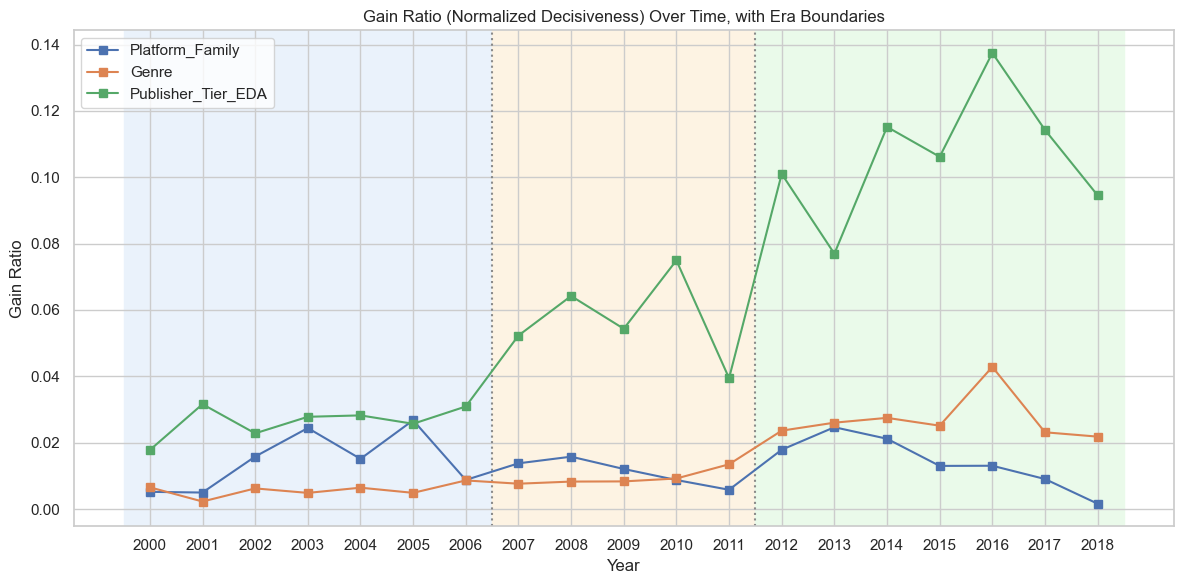

In [30]:
os.makedirs('evidence/figures', exist_ok=True)

era_spans = [(2000, 2006, '#eaf2fb'), (2007, 2011, '#fdf3e3'), (2012, 2018, '#eafaea')]
era_bounds = [2007, 2012]

def add_eras(ax):
    for a, b, col in era_spans:
        ax.axvspan(a - 0.5, b + 0.5, color=col, zorder=0)
    for yb in era_bounds:
        ax.axvline(yb - 0.5, color='grey', linestyle=':', alpha=0.9)

# Plot 1: Information Gain (with era shading + boundaries + step annotations)
fig, ax = plt.subplots(figsize=(12, 6))
add_eras(ax)
for col in features:
    lw = 3 if col == 'Publisher_Tier_EDA' else 1.5
    ax.plot(ig_df.index, ig_df[col], marker='o', label=col, linewidth=lw)
ax.annotate('Tier step-up #1 (2007)', xy=(2007, ig_df['Publisher_Tier_EDA'].loc[2007]),
            xytext=(2007.3, 0.135), arrowprops=dict(arrowstyle='->'))
ax.annotate('Tier step-up #2 (2012)', xy=(2012, ig_df['Publisher_Tier_EDA'].loc[2012]),
            xytext=(2009.2, 0.205), arrowprops=dict(arrowstyle='->'))
ax.set_title('Information Gain (Feature Decisiveness) Over Time, with Era Boundaries')
ax.set_xlabel('Year')
ax.set_ylabel('Information Gain (bits)')
ax.set_xticks(years)
ax.legend()
plt.tight_layout()
plt.savefig('evidence/figures/a1c_information_gain_over_time.png')
plt.show()

# Plot 2: Gain Ratio (same era context)
fig, ax = plt.subplots(figsize=(12, 6))
add_eras(ax)
for col in features:
    ax.plot(gr_df.index, gr_df[col], marker='s', label=col)
ax.set_title('Gain Ratio (Normalized Decisiveness) Over Time, with Era Boundaries')
ax.set_xlabel('Year')
ax.set_ylabel('Gain Ratio')
ax.set_xticks(years)
ax.legend()
plt.tight_layout()
plt.savefig('evidence/figures/a1c_gain_ratio_over_time.png')
plt.show()


**Chart brief: feature decisiveness over time.** Each line is a feature's Information Gain about Hit, computed separately for every year (Lec 7). The shaded bands are the three proposed eras and the dotted lines are the boundaries. Publisher_Tier (thick line) is the most decisive feature in almost every year, and its decisiveness is not flat: it rises from a low plateau over 2000 to 2006, to a higher one after 2007, then jumps again after 2012, where Genre also becomes more decisive. Platform_Family stays weak throughout and fades toward 2018, consistent with the dead-feature reading from Part 1. Because the boundaries come from where the model's own split criterion changes level, they are data driven rather than chosen by feel.

## 4.6 Data-driven breakpoints (non-overlapping bands)

In [31]:
ig = ig_df['Publisher_Tier_EDA']
gr = gr_df['Publisher_Tier_EDA']

eras = {'2000-2006': (2000, 2006), '2007-2011': (2007, 2011), '2012-2018': (2012, 2018)}

def band_report(series, label):
    print(f"{label} of Publisher_Tier per era (min .. max, mean):")
    prev_max = None
    for name, (a, b) in eras.items():
        v = series.loc[a:b]
        line = f"  {name}: {v.min():.3f} .. {v.max():.3f}   mean {v.mean():.3f}"
        if prev_max is not None:
            gap = v.min() - prev_max
            line += f"   | gap to prev band: {gap:+.3f} ({'no overlap' if gap > 0 else 'OVERLAP'})"
        print(line)
        prev_max = v.max()
    print()

# The yearly series is wavy inside each era, so single-year jumps are not reliable.
# The structural test is whether the three eras occupy separate (non-overlapping) bands.
band_report(ig, "Information Gain")
band_report(gr, "Gain Ratio")

print("Reading (honest):")
print("- We do not rely on single-year jumps; the within-era series is noisy.")
print("- The test that matters: the three eras occupy non-overlapping bands. Each later")
print("  era's lowest year still exceeds the previous era's highest year, under BOTH")
print("  Information Gain and Gain Ratio, so the 2007 and 2012 level shifts are not an")
print("  artifact of the IG-vs-GR choice.")
print("- Caveats: 2012 is the strongest break; the 2011/2012 separation is the thinnest")
print("  (gap about +0.008 IG, +0.002 GR). This is descriptive evidence, then tested")
print("  against the no-cutoff and single-segment scopes in Phase C4.")


Information Gain of Publisher_Tier per era (min .. max, mean):
  2000-2006: 0.027 .. 0.047   mean 0.038
  2007-2011: 0.058 .. 0.113   mean 0.085   | gap to prev band: +0.012 (no overlap)
  2012-2018: 0.121 .. 0.211   mean 0.164   | gap to prev band: +0.008 (no overlap)

Gain Ratio of Publisher_Tier per era (min .. max, mean):
  2000-2006: 0.018 .. 0.032   mean 0.026
  2007-2011: 0.039 .. 0.075   mean 0.057   | gap to prev band: +0.008 (no overlap)
  2012-2018: 0.077 .. 0.137   mean 0.107   | gap to prev band: +0.002 (no overlap)

Reading (honest):
- We do not rely on single-year jumps; the within-era series is noisy.
- The test that matters: the three eras occupy non-overlapping bands. Each later
  era's lowest year still exceeds the previous era's highest year, under BOTH
  Information Gain and Gain Ratio, so the 2007 and 2012 level shifts are not an
  artifact of the IG-vs-GR choice.
- Caveats: 2012 is the strongest break; the 2011/2012 separation is the thinnest
  (gap about +0.008 

## 7. Verdict

The decisive feature is Publisher_Tier. Its yearly Information Gain is wavy within each era, so we do not read individual year jumps. The structural test is whether the eras form separate bands, and they do: the three eras occupy non-overlapping ranges, where each later era's lowest year still exceeds the previous era's highest year. This holds under both Information Gain and Gain Ratio, so the result does not depend on which measure we pick. The band means rise from about 0.038 over 2000 to 2006, to about 0.085 over 2007 to 2011, to about 0.164 over 2012 to 2018. 2012 is the strongest break and the 2011 to 2012 separation is the thinnest. Genre also becomes more decisive from 2012, while Platform_Family stays weak throughout and fades toward 2018 (consistent with Part 1).

These data-driven boundaries define scope variant 3 (eras 2000-2006, 2007-2011, 2012-2018). They come from the model's own split criterion (information gain, Lec 7), not intuition, and they replace the earlier off-syllabus Cramer's V version. We do not treat them as the only valid cut points: scope variant 3 is compared against the no-cutoff and single-segment scopes in Phase C, so this segmentation is a hypothesis we test, not an assumption.